In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. Create a simple dataset with outliers
np.random.seed(42)
X = np.sort(np.random.rand(30, 1) * 5, axis=0)
y = 1.5 * X.squeeze() + 2 + np.random.randn(30) * 1.5
y[2] += 8   # High outlier
y[-3] -= 5  # Low outlier

In [ ]:
# 2. Scale the data (Mandatory for Regularization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 3. Initialize and fit models
# alpha is the penalty strength (higher alpha = more regularization)
models = {
    "OLS": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=10),
    "Lasso (L1)": Lasso(alpha=1)
}

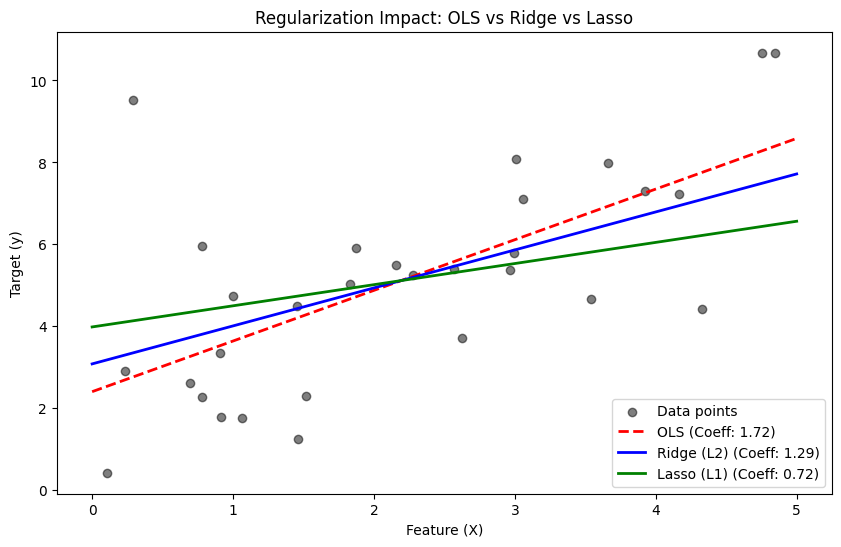

In [ ]:
# 4. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Data points', alpha=0.5)

X_test = np.linspace(0, 5, 100).reshape(-1, 1)
X_test_scaled = scaler.transform(X_test)

colors = {'OLS': 'red', 'Ridge (L2)': 'blue', 'Lasso (L1)': 'green'}
line_styles = {'OLS': '--', 'Ridge (L2)': '-', 'Lasso (L1)': '-'}

for name, model in models.items():
    model.fit(X_scaled, y)
    y_pred = model.predict(X_test_scaled)
    plt.plot(X_test, y_pred, label=f"{name} (Coeff: {model.coef_[0]:.2f})",
             color=colors[name], linestyle=line_styles[name], linewidth=2)

plt.title("Regularization Impact: OLS vs Ridge vs Lasso")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()


#### OLS Ridge and Lasso regressionon multidimentional space

In [ ]:
# 1. Create a dataset with 5 features
# 2 important features, 3 "noise" features
np.random.seed(42)
n_samples = 100
n_features = 5
X = np.random.randn(n_samples, n_features)
# True relationship only depends on first two features
y = 3 * X[:, 0] + 1.5 * X[:, 1] + np.random.normal(0, 1, n_samples)
# Imagine we are trying to predict how many minutes it takes for a pizza to arrive based on 5 factors (features):
feature_names = ["Distance",
"Number of Traffic Lights",
"The Color of the Delivery Car",
"The Driver's Favorite Movie",
"The Day of the Week the Driver was Born "]

In [ ]:
# 2. Scale
scaler = StandardScaler()
X_s = scaler.fit_transform(X)


In [ ]:
# 3. Fit Models
# Using high alpha for Lasso to demonstrate feature selection (zeroing out)
models = {
    'OLS': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=20),
    'Lasso (L1)': Lasso(alpha=0.5)
}
results = {}
for name, model in models.items():
    model.fit(X_s, y)
    results[name] = model.coef_

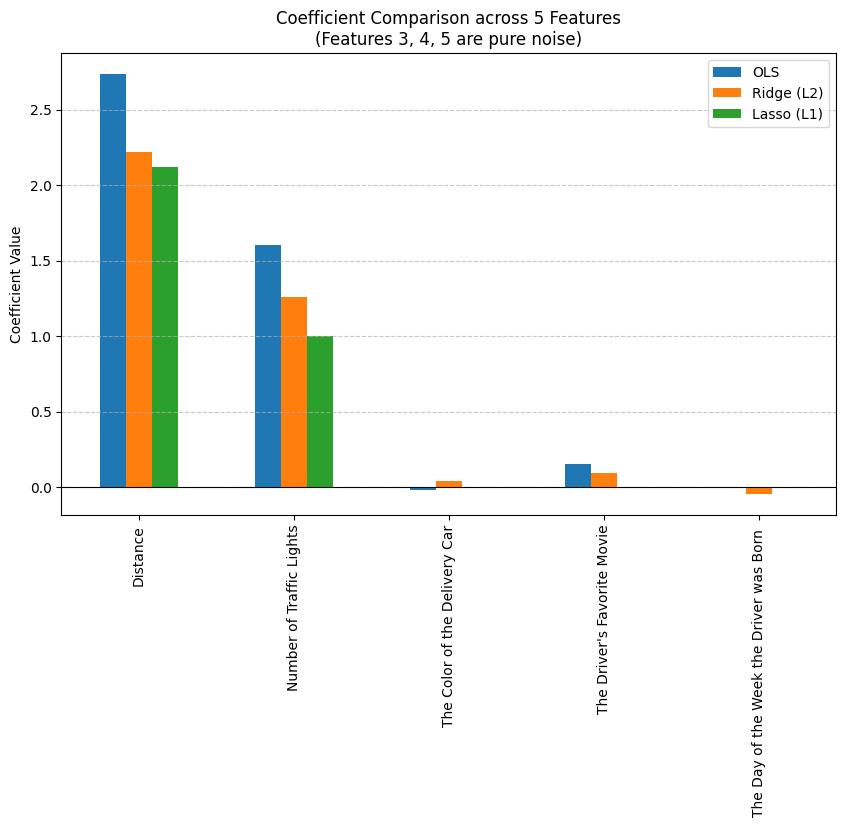

                                               OLS  Ridge (L2)  Lasso (L1)
Distance                                  2.736084    2.222752    2.122863
Number of Traffic Lights                  1.601455    1.262235    1.004099
The Color of the Delivery Car            -0.020847    0.038284    0.000000
The Driver's Favorite Movie               0.153473    0.095293    0.000000
The Day of the Week the Driver was Born  -0.007719   -0.045474   -0.000000


In [ ]:
# 4. Plotting
df_coef = pd.DataFrame(results, index=feature_names)
df_coef.plot(kind='bar', figsize=(10, 6))
plt.title('Coefficient Comparison across 5 Features\n(Features 3, 4, 5 are pure noise)')
plt.ylabel('Coefficient Value')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Print the values for the user
print(df_coef)


#### how the Ridge and lasso filters the importance of features?

In [ ]:
# 1. Create a grid of possible coefficient values (w1 and w2)
w1 = np.linspace(-0.5, 1.5, 100)
w2 = np.linspace(-0.5, 1.5, 100)
W1, W2 = np.meshgrid(w1, w2)



In [ ]:
# 2. Define the OLS Loss (The Red Ellipses)
# We center the minimum error at (1.0, 0.7)
# This is where a standard Linear Regression wants to go.
OLS_loss = 2*(W1 - 1.0)**2 + (W2 - 0.7)**2


In [ ]:
# 3. Define the Regularization Constraints (The Shaded Regions)
L2_penalty = W1**2 + W2**2             # Ridge Circle
L1_penalty = np.abs(W1) + np.abs(W2)   # Lasso Diamond


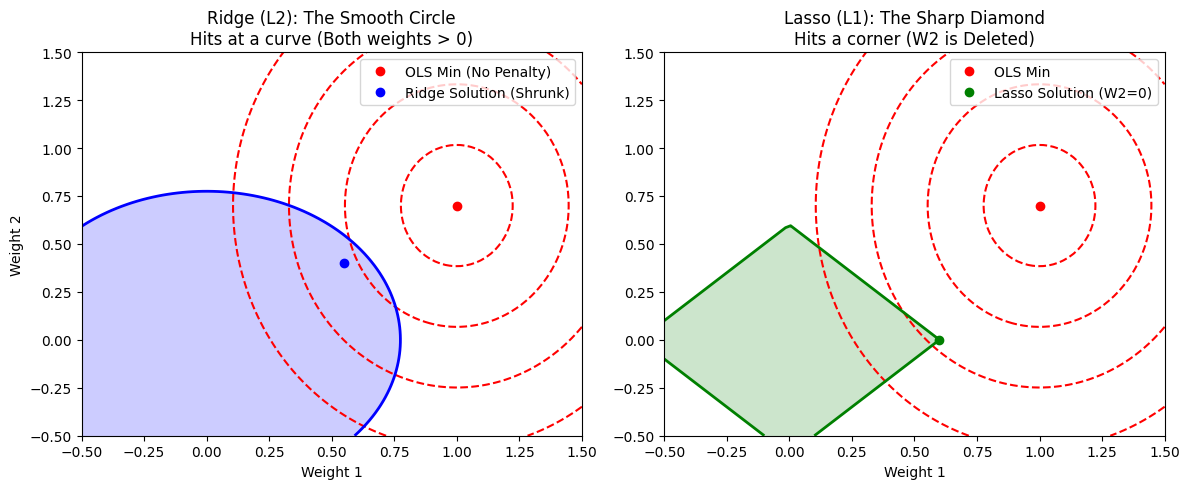

In [ ]:

# 4. Set up the plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Ridge (L2) ---
# Draw the error contours
ax1.contour(W1, W2, OLS_loss, levels=[0.1, 0.4, 0.9, 1.6], colors='red', linestyles='dashed')
# Draw the Ridge "Budget"
ax1.contourf(W1, W2, L2_penalty, levels=[0, 0.6], colors='blue', alpha=0.2)
ax1.contour(W1, W2, L2_penalty, levels=[0.6], colors='blue', linewidths=2)
# Mark the points
ax1.plot(1.0, 0.7, 'ro', label='OLS Min (No Penalty)')
ax1.plot(0.55, 0.4, 'bo', label='Ridge Solution (Shrunk)')
ax1.set_title("Ridge (L2): The Smooth Circle\nHits at a curve (Both weights > 0)")
ax1.set_xlabel("Weight 1"); ax1.set_ylabel("Weight 2")
ax1.legend()
# --- Plot 2: Lasso (L1) ---
# Draw the error contours
ax2.contour(W1, W2, OLS_loss, levels=[0.1, 0.4, 0.9, 1.6], colors='red', linestyles='dashed')
# Draw the Lasso "Budget"
ax2.contourf(W1, W2, L1_penalty, levels=[0, 0.6], colors='green', alpha=0.2)
ax2.contour(W1, W2, L1_penalty, levels=[0.6], colors='green', linewidths=2)
# Mark the points
ax2.plot(1.0, 0.7, 'ro', label='OLS Min')
ax2.plot(0.6, 0.0, 'go', label='Lasso Solution (W2=0)')
ax2.set_title("Lasso (L1): The Sharp Diamond\nHits a corner (W2 is Deleted)")
ax2.set_xlabel("Weight 1")
ax2.legend()


plt.tight_layout()
plt.show()
